# This script shall serve to generate the gff3 file for promoters from TSS data

Subsequently, the script shall extract the DNA sequences of the promoters from the fasta file.

In [59]:
import pandas as pd
import numpy as np

In [60]:
# Read the gff3 file

gff3 = pd.read_csv("/Users/maikschauerte/Desktop/NAR_Revision/PhageEpitranscriptomics-main/NAD_captureSeq/TSSs_NC_000866-4_R2.gff", sep = '\t', header = None)
gff3.columns = ['Chr', 'type', 'feature', 'start', 'end', 'fill1', 'strand', 'fill2', 'features', 'gene']
gff3

,Chr,type,feature,start,end,fill1,strand,fill2,features,gene
0,NC_000866.4,manual,TSS,3196,3196,.,-,.,ID=60.1;Name=60.1_TSS,60.1
1,NC_000866.4,manual,TSS,6594,6594,.,-,.,ID=cef;Name=cef_TSS,cef
2,NC_000866.4,manual,TSS,11138,11138,.,-,.,ID=dda.1;Name=dda.1_TSS,dda.1
3,NC_000866.4,manual,TSS,15252,15252,.,-,.,ID=mrh.2;Name=mrh.2_TSS,mrh.2
4,NC_000866.4,manual,TSS,16797,16813,.,-,.,ID=56;Name=56_TSS,56
5,NC_000866.4,manual,TSS,20070,20073,.,-,.,ID=sp;Name=sp_TSS,sp
6,NC_000866.4,manual,TSS,27044,27044,.,-,.,ID=imm.1;Name=imm.1_TSS,imm.1
7,NC_000866.4,manual,TSS,29931,29931,.,-,.,ID=43;Name=43_TSS,43
8,NC_000866.4,manual,TSS,35662,35662,.,-,.,ID=47;Name=47_TSS,47
9,NC_000866.4,manual,TSS,39447,39447,.,-,.,ID=a-gt.4;Name=a-gt.4_TSS,a-gt.4


In [61]:
# Change start or end position by 50 nts depending on the strand

promotersGFF = gff3
for i in range(0,gff3.shape[0]):
    NadRNA = gff3.iloc[i,]
    if NadRNA['strand'] == '+':
        start = NadRNA['start'] - 50
        promotersGFF.loc[i,'start'] = start
    elif NadRNA['strand'] == '-':
        end = NadRNA['end'] + 50
        promotersGFF.loc[i,'end'] = end

promotersGFF

,Chr,type,feature,start,end,fill1,strand,fill2,features,gene
0,NC_000866.4,manual,TSS,3196,3246,.,-,.,ID=60.1;Name=60.1_TSS,60.1
1,NC_000866.4,manual,TSS,6594,6644,.,-,.,ID=cef;Name=cef_TSS,cef
2,NC_000866.4,manual,TSS,11138,11188,.,-,.,ID=dda.1;Name=dda.1_TSS,dda.1
3,NC_000866.4,manual,TSS,15252,15302,.,-,.,ID=mrh.2;Name=mrh.2_TSS,mrh.2
4,NC_000866.4,manual,TSS,16797,16863,.,-,.,ID=56;Name=56_TSS,56
5,NC_000866.4,manual,TSS,20070,20123,.,-,.,ID=sp;Name=sp_TSS,sp
6,NC_000866.4,manual,TSS,27044,27094,.,-,.,ID=imm.1;Name=imm.1_TSS,imm.1
7,NC_000866.4,manual,TSS,29931,29981,.,-,.,ID=43;Name=43_TSS,43
8,NC_000866.4,manual,TSS,35662,35712,.,-,.,ID=47;Name=47_TSS,47
9,NC_000866.4,manual,TSS,39447,39497,.,-,.,ID=a-gt.4;Name=a-gt.4_TSS,a-gt.4


In [62]:
# Read fasta reference genome into file refGenome

with open('/Users/maikschauerte/Desktop/NAR_Revision/PhageEpitranscriptomics-main/Reference_genomes/NC_000866.4.fasta') as f:
    lines = f.readlines()
    key = lines[0].strip()
    sequence = lines[1].strip()
    for i in range(2,len(lines)):
        sequence = sequence + lines[i].strip()

    refGenome = sequence

refGenome

'...'

In [63]:
# Retrieve promoter sequences and add to promotersGFF

promoterSeqs = promotersGFF

for i in range(0, promotersGFF.shape[0]):
    reference = list(refGenome)
    promoter = ''.join(reference[promotersGFF.loc[i,'start']:promotersGFF.loc[i,'end']+1])
    promoterSeqs.loc[i,'Sequence'] = promoter

promoterSeqs['Sequence']


0     GATTTATTATACCATGGTTTCGCTTTTTCAAGTTCAGCTGCTTTTG...
1     ATTGATATAGTACCATAATCAACTACTGATGTATATAGTTTTATGA...
2     TGAATAATTTTATCACACATATCATATTGCATTTCTGCTTCTGACA...
3     AATTCTATTATACCATACTCATTTTGGAAAGTAAACCATTTAAATG...
4     CAATTCATTAATAAGTTAAATAATTATATCATTTGAGTATGTAAGC...
5     TATGTTTATATAGTATCTCAATTTCCAACAAAAGTAAACAGTTATT...
6     AGTTGTATAGTACCATGGAAGAACAGTCTTGTAAACAGTTTTGTGA...
7     TGATATATTATACTCCAAATAAGGGGCCGAAGCCCCTTGCTTAATT...
8     TCAGTTACTATAACACGTACTGATAGATTTGTAAAATCTTTATAGT...
9     AGTTTAATTCTACACCATTAGATTTAAAAGCGGTATCATACGGATT...
10    TCATAGATCTATTATATCATAATATTTGAAGACCTATCTTAAAGCA...
11    TCCTCAAAGGTAATTCATATGTTAATAATACCACGGTTTGAACTTG...
12    ACTACGATTATAACAACCTTCGCATTTATGCAAACATCCAGTGACG...
13    ATTCATATTTATACGAGGATAAACAGCTGCATGTCACCATGCAGTT...
14    AATCTCCTCAGTAGAAAGTAAGAACATTATACCACATCCTTGTGGC...
15    AGTTGTATAGTACCACAGAGGAACGGTCTTGTAAACAACTAAAAGA...
16    AGTTGTATAGTACCATAAAGCTTTATGCTTGTAAACCGTTTTGTGA...
17    GGTTGTATAGTACCACAGCTCAAACGGAAAGTAAACCGGTAA

In [64]:
# Generate the reverse complement sequence for the - strand promoters

# Define reverse complement function

def revComplement (sequence):
    complements = dict(A = 'T', C = 'G', G = 'C', T = 'A')
    reverse_complement = "".join(complements.get(base, base) for base in reversed(sequence))
    return reverse_complement

promoterSeqsOut = promoterSeqs.copy()

for i in range(0, promoterSeqs.shape[0]):
    if promoterSeqs.loc[i,'strand'] == '-':
        revComp = revComplement(promoterSeqs.loc[i,'Sequence'])
        promoterSeqsOut.loc[i,'Sequence'] = revComp
    else:
        promoterSeqsOut.loc[i,'Sequence'] = promoterSeqs.loc[i,'Sequence']

In [65]:
# Get the last 51 bases of the motif

def getMotifBases(sequence):
    seq = list(sequence)
    if len(seq) > 51:
        print("Promoter longer than 51 bases.")
    elif len(seq) < 40:
        print("Promoter shorter than 40 bases.")
    elif len(seq) == 51:
        print("Promoter is exactly 51 bases long.")
    returnSeq = ''.join(seq[-51:])
    return returnSeq

promotersForMotifs = promoterSeqsOut.copy()

for i in range(0, promotersForMotifs.shape[0]):
    promotersForMotifs.loc[i,'Sequence'] = getMotifBases(promotersForMotifs.loc[i,'Sequence'])

promotersForMotifs

Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter longer than 51 bases.
Promoter longer than 51 bases.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter longer than 51 bases.
Promoter longer than 51 bases.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter longer than 51 bases.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter longer than 51 bases.
Promoter is exactly 51 bases long.
Promoter longer than 51 bases.
Promoter longer than 51 bases.
Promoter longer than 51 bases.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter is exactly 51 bases long.
Promoter longer than 51 bases.
Promoter is exactly 51 bases long.
Promoter longer than 51 b

,Chr,type,feature,start,end,fill1,strand,fill2,features,gene,Sequence
0,NC_000866.4,manual,TSS,3196,3246,.,-,.,ID=60.1;Name=60.1_TSS,60.1,TACTGCAAAAGCAGCTGAACTTGAAAAAGCGAAACCATGGTATAAT...
1,NC_000866.4,manual,TSS,6594,6644,.,-,.,ID=cef;Name=cef_TSS,cef,ATTTTTCATAAAACTATATACATCAGTAGTTGATTATGGTACTATA...
2,NC_000866.4,manual,TSS,11138,11188,.,-,.,ID=dda.1;Name=dda.1_TSS,dda.1,AAAGTTGTCAGAAGCAGAAATGCAATATGATATGTGTGATAAAATT...
3,NC_000866.4,manual,TSS,15252,15302,.,-,.,ID=mrh.2;Name=mrh.2_TSS,mrh.2,TTTTTCATTTAAATGGTTTACTTTCCAAAATGAGTATGGTATAATA...
4,NC_000866.4,manual,TSS,16797,16863,.,-,.,ID=56;Name=56_TSS,56,TAATTGCTTACATACTCAAATGATATAATTATTTAACTTATTAATG...
5,NC_000866.4,manual,TSS,20070,20123,.,-,.,ID=sp;Name=sp_TSS,sp,TTTAAAATAACTGTTTACTTTTGTTGGAAATTGAGATACTATATAA...
6,NC_000866.4,manual,TSS,27044,27094,.,-,.,ID=imm.1;Name=imm.1_TSS,imm.1,TTTTTTCACAAAACTGTTTACAAGACTGTTCTTCCATGGTACTATA...
7,NC_000866.4,manual,TSS,29931,29981,.,-,.,ID=43;Name=43_TSS,43,TTGGTAATTAAGCAAGGGGCTTCGGCCCCTTATTTGGAGTATAATA...
8,NC_000866.4,manual,TSS,35662,35712,.,-,.,ID=47;Name=47_TSS,47,AATTGACTATAAAGATTTTACAAATCTATCAGTACGTGTTATAGTA...
9,NC_000866.4,manual,TSS,39447,39497,.,-,.,ID=a-gt.4;Name=a-gt.4_TSS,a-gt.4,CAGAAAATCCGTATGATACCGCTTTTAAATCTAATGGTGTAGAATT...


# Inspect promoter sequences briefly

In [66]:
# Take a look at the promoters

promotersForMotifs['Sequence']

0     TACTGCAAAAGCAGCTGAACTTGAAAAAGCGAAACCATGGTATAAT...
1     ATTTTTCATAAAACTATATACATCAGTAGTTGATTATGGTACTATA...
2     AAAGTTGTCAGAAGCAGAAATGCAATATGATATGTGTGATAAAATT...
3     TTTTTCATTTAAATGGTTTACTTTCCAAAATGAGTATGGTATAATA...
4     TAATTGCTTACATACTCAAATGATATAATTATTTAACTTATTAATG...
5     TTTAAAATAACTGTTTACTTTTGTTGGAAATTGAGATACTATATAA...
6     TTTTTTCACAAAACTGTTTACAAGACTGTTCTTCCATGGTACTATA...
7     TTGGTAATTAAGCAAGGGGCTTCGGCCCCTTATTTGGAGTATAATA...
8     AATTGACTATAAAGATTTTACAAATCTATCAGTACGTGTTATAGTA...
9     CAGAAAATCCGTATGATACCGCTTTTAAATCTAATGGTGTAGAATT...
10    CTCTATGCTTTAAGATAGGTCTTCAAATATTATGATATAATAGATC...
11    TACAACAAGTTCAAACCGTGGTATTATTAACATATGAATTACCTTT...
12    CTCTTCGTCACTGGATGTTTGCATAAATGCGAAGGTTGTTATAATC...
13    GTCTGAACTGCATGGTGACATGCAGCTGTTTATCCTCGTATAAATA...
14    ACTTTGCCACAAGGATGTGGTATAATGTTCTTACTTTCTACTGAGG...
15    AAGTTTCTTTTAGTTGTTTACAAGACCGTTCCTCTGTGGTACTATA...
16    TTTTTTCACAAAACGGTTTACAAGCATAAAGCTTTATGGTACTATA...
17    TTTTTCATTTTACCGGTTTACTTTCCGTTTGAGCTGTGGTAC

In [67]:
# Plot a histogram of the sequences

inputSeqs = list(promotersForMotifs['Sequence'].drop(12))

# Reverse sequences, count abundance

frequencies = pd.Series()
i = 0

while i < 51:
    
    A = 0
    C = 0
    G = 0
    T = 0
    
    for sequence in inputSeqs:
        
        base = list(reversed(sequence))[i]
        if base == 'A':
            A += 1
        elif base == 'C':
            C += 1
        elif base == 'G':
            G += 1
        elif base == 'T':
            T += 1
    
    posFreq = pd.Series(data = dict(A = A, C = C, G = G, T = T), index = ['A', 'C', 'G', 'T'])
    frequencies = pd.concat([frequencies, posFreq], ignore_index = False, axis = 1)
    
    i += 1

frequencies = frequencies.iloc[:,1:frequencies.shape[1]]
frequencies.columns = range(0, 51)
frequencies


/var/folders/zg/nym4yv2j07zbmv_y9x2zfprr0000gn/T/ipykernel_23620/2654563486.py:7: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  frequencies = pd.Series()


,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,50
A,12,11,17,23,13,19,8,27,22,12,...,16,10,15,16,12,16,6,10,12,9
C,4,13,1,4,11,3,1,1,2,9,...,4,10,4,11,5,1,3,9,2,4
G,4,5,4,3,8,3,1,5,2,2,...,3,4,5,2,6,4,7,5,5,8
T,18,9,16,8,6,13,28,5,12,15,...,15,14,14,9,15,17,22,14,19,17


In [68]:
frequencies = frequencies.transpose()
frequencies['Position'] = frequencies.index
df = pd.melt(frequencies, id_vars='Position')
df

,Position,variable,value
0,0,A,12
1,1,A,11
2,2,A,17
3,3,A,23
4,4,A,13
...,...,...,...
199,46,T,17
200,47,T,22
201,48,T,14
202,49,T,19


<Axes: xlabel='Position', ylabel='value'>

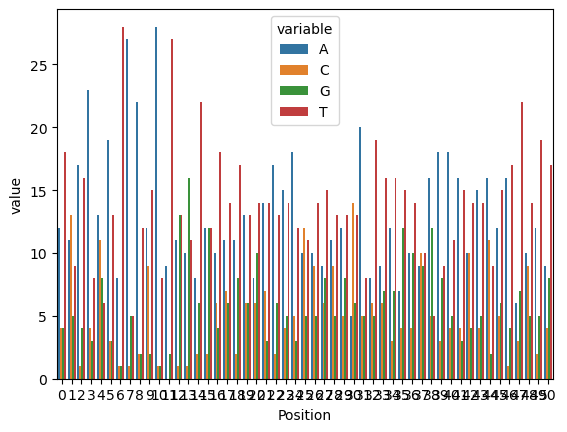

In [69]:
import seaborn as sns

sns.barplot(data=df, x = "Position", y = "value", hue = "variable")

# Inspect infection phase-specific promoter sequences

In [70]:
# Get subset of sequences for RNAs of interest, these are stored in an excel file

earlyR1 = pd.read_excel("/Users/maikschauerte/Desktop/NAR_Revision/Phage_NAD-RNA_analysis/Phase-specific_T4_NAD-RNAs.xlsx", sheet_name = "early_R1")
earlyR2 = pd.read_excel("/Users/maikschauerte/Desktop/NAR_Revision/Phage_NAD-RNA_analysis/Phase-specific_T4_NAD-RNAs.xlsx", sheet_name = "early_R2")

middleR1 = pd.read_excel("/Users/maikschauerte/Desktop/NAR_Revision/Phage_NAD-RNA_analysis/Phase-specific_T4_NAD-RNAs.xlsx", sheet_name = "middle_R1")
middleR2 = pd.read_excel("/Users/maikschauerte/Desktop/NAR_Revision/Phage_NAD-RNA_analysis/Phase-specific_T4_NAD-RNAs.xlsx", sheet_name = "middle_R2")

lateR1 = pd.read_excel("/Users/maikschauerte/Desktop/NAR_Revision/Phage_NAD-RNA_analysis/Phase-specific_T4_NAD-RNAs.xlsx", sheet_name = "late_R1")
lateR2 = pd.read_excel("/Users/maikschauerte/Desktop/NAR_Revision/Phage_NAD-RNA_analysis/Phase-specific_T4_NAD-RNAs.xlsx", sheet_name = "late_R2")

In [71]:
# List of all NAD-RNA T4 phage genes

all_found = pd.concat([earlyR2, middleR2, lateR2], axis = 0)
all_found

,Geneid,Entity,t0,t1,t4,t7,t10,t20,Gene,Gene Type,Funtion/Product
0,gene-T4p010,NC_000866.4,-,+,+,-,-,-,cef,protein_coding,cytochrome C biogenesis protein CcmE
1,gene-T4p071,NC_000866.4,-,+,+,+,+,+,55.6,protein_coding,gp55.6 conserved hypothetical protein
2,gene-T4p092,NC_000866.4,-,+,+,-,+,+,nrdC.8,protein_coding,NrdC.8 conserved hypothetical protein
3,gene-T4p094,NC_000866.4,-,+,+,-,-,-,nrdC.10,protein_coding,NrdC.10 conserved hypothetical protein
4,gene-T4p242,NC_000866.4,-,+,+,+,+,-,frd.3,protein_coding,Frd.3 hypothetical protein
5,gene-T4p018,NC_000866.4,-,-,+,+,+,+,dda.1,protein_coding,Dda.1 hypothetical protein
6,gene-T4p019,NC_000866.4,-,-,+,+,+,+,srd,protein_coding,Srd anti-sigma factor%2C putative
7,gene-T4p028,NC_000866.4,-,-,+,+,+,-,mrh.2,protein_coding,Mrh.2 hypothetical protein
8,gene-T4p031,NC_000866.4,-,-,+,+,+,+,56,protein_coding,dUTP diphosphatase
9,gene-T4p036,NC_000866.4,-,-,+,+,+,-,sp,protein_coding,sp spackle periplasmic protein


In [72]:
# Identify genes that are not yet present in annotation for ONTrun_061

foundGenes = list(all_found['Gene']) # all NAD-RNA genes (early, middle, late from R1)

def changeToString(genes):
    return [str(i) for i in genes]

allGenes = sorted(changeToString(foundGenes)) # sorted and converted to string

##

annotatedTSSs = sorted(changeToString(list(gff3['gene'])))

len(annotatedTSSs), len(allGenes)

##

list(set(allGenes) - set(annotatedTSSs)) # missing genes in TSS annotation so far

['nrdB', '22', 'tk.4', 'e', '46', 'srd', '1', 'e.8', 'dam', '11', '6']

## Overlap between replicates to use for common promoters

In [73]:
# Define a function to get only overlapping genes

def overlapNADRNAs(df1, df2):
    genesR1 = list(df1['Geneid'])
    genesR2 = list(df2['Geneid'])

    substractGenes = list(set(genesR1) - set(genesR2))
    commonGenes = list(set(genesR1) - set(substractGenes))

    df1.index = df1['Geneid']
    df_out = df1.loc[commonGenes]

    return df_out

In [74]:
early = overlapNADRNAs(earlyR1, earlyR2)
early.shape, earlyR1.shape, earlyR2.shape


((19, 11), (23, 11), (20, 11))

In [75]:
early

,Geneid,Entity,t0,t1,t4,t7,t10,t20,Gene,Gene Type,Funtion/Product
Geneid,,,,,,,,,,,
gene-T4p219,gene-T4p219,NC_000866.4,-,-,+,+,+,-,cd.2,protein_coding,Cd.2 conserved hypothetical protein
gene-T4p092,gene-T4p092,NC_000866.4,-,+,+,+,-,-,nrdC.8,protein_coding,NrdC.8 conserved hypothetical protein
gene-T4p227,gene-T4p227,NC_000866.4,-,-,+,+,+,-,alc,protein_coding,Alc inhibitor of host transcription
gene-T4p031,gene-T4p031,NC_000866.4,-,-,+,-,+,+,56,protein_coding,dUTP diphosphatase
gene-T4p010,gene-T4p010,NC_000866.4,-,+,+,-,-,-,cef,protein_coding,cytochrome C biogenesis protein CcmE
gene-T4p046,gene-T4p046,NC_000866.4,-,+,+,-,-,-,imm.1,protein_coding,iduronate sulfatase
gene-T4p036,gene-T4p036,NC_000866.4,-,-,+,-,-,-,sp,protein_coding,sp spackle periplasmic protein
gene-T4p102,gene-T4p102,NC_000866.4,-,+,+,+,+,-,mobD.5,protein_coding,MobD.5 hypothetical protein
gene-T4p071,gene-T4p071,NC_000866.4,-,+,+,+,+,-,55.6,protein_coding,gp55.6 conserved hypothetical protein


In [76]:
middle = overlapNADRNAs(middleR1, middleR2)
middle.shape, middleR1.shape, middleR2.shape


((7, 11), (13, 11), (11, 11))

In [77]:
middle

,Geneid,Entity,t0,t1,t4,t7,t10,t20,Gene,Gene Type,Funtion/Product
Geneid,,,,,,,,,,,
gene-T4p032,gene-T4p032,NC_000866.4,-,-,-,+,-,-,dam,protein_coding,Dam family site-specific DNA-(adenine-N6)-meth...
gene-T4p245,gene-T4p245,NC_000866.4,-,-,-,+,+,+,59,protein_coding,59 protein
gene-T4p139,gene-T4p139,NC_000866.4,-,-,-,+,+,-,1,protein_coding,deoxynucleoside monophosphate kinase
gene-T4p063,gene-T4p063,NC_000866.4,-,-,-,+,-,-,a-gt.4,protein_coding,a-gt.4 family protein
gene-T4p054,gene-T4p054,NC_000866.4,-,-,-,+,-,-,46,protein_coding,AAA family ATPase
gene-T4p214,gene-T4p214,NC_000866.4,-,-,-,+,+,+,31,protein_coding,co-chaperone GroES family protein
gene-T4p004,gene-T4p004,NC_000866.4,-,-,-,-,+,-,60.1,protein_coding,gp60.1 hypothetical protein


In [78]:
late = overlapNADRNAs(lateR1, lateR2)
late.shape, lateR1.shape, lateR2.shape


((3, 11), (10, 11), (13, 11))

In [79]:
late

,Geneid,Entity,t0,t1,t4,t7,t10,t20,Gene,Gene Type,Funtion/Product
Geneid,,,,,,,,,,,
gene-T4p185,gene-T4p185,NC_000866.4,-,-,-,-,-,+,uvsY.-2,protein_coding,DUF2685 domain-containing protein
gene-T4p191,gene-T4p191,NC_000866.4,-,-,-,-,-,+,51,protein_coding,baseplate hub assembly protein
gene-T4p143,gene-T4p143,NC_000866.4,-,-,-,-,-,+,53,protein_coding,baseplate wedge protein 53


# Get promoter sequences for overlapping sets of NAD-RNAs

In [80]:
def changeToString(genes):
    return [str(i) for i in genes]

In [81]:
Genes = changeToString(list(early['Gene']))
early_promoters = promotersForMotifs.loc[promotersForMotifs['gene'].isin(Genes)]
early_promoters

,Chr,type,feature,start,end,fill1,strand,fill2,features,gene,Sequence
1,NC_000866.4,manual,TSS,6594,6644,.,-,.,ID=cef;Name=cef_TSS,cef,ATTTTTCATAAAACTATATACATCAGTAGTTGATTATGGTACTATA...
2,NC_000866.4,manual,TSS,11138,11188,.,-,.,ID=dda.1;Name=dda.1_TSS,dda.1,AAAGTTGTCAGAAGCAGAAATGCAATATGATATGTGTGATAAAATT...
3,NC_000866.4,manual,TSS,15252,15302,.,-,.,ID=mrh.2;Name=mrh.2_TSS,mrh.2,TTTTTCATTTAAATGGTTTACTTTCCAAAATGAGTATGGTATAATA...
4,NC_000866.4,manual,TSS,16797,16863,.,-,.,ID=56;Name=56_TSS,56,TAATTGCTTACATACTCAAATGATATAATTATTTAACTTATTAATG...
5,NC_000866.4,manual,TSS,20070,20123,.,-,.,ID=sp;Name=sp_TSS,sp,TTTAAAATAACTGTTTACTTTTGTTGGAAATTGAGATACTATATAA...
6,NC_000866.4,manual,TSS,27044,27094,.,-,.,ID=imm.1;Name=imm.1_TSS,imm.1,TTTTTTCACAAAACTGTTTACAAGACTGTTCTTCCATGGTACTATA...
8,NC_000866.4,manual,TSS,35662,35712,.,-,.,ID=47;Name=47_TSS,47,AATTGACTATAAAGATTTTACAAATCTATCAGTACGTGTTATAGTA...
11,NC_000866.4,manual,TSS,41652,41720,.,-,.,ID=55.6;Name=55.6_TSS,55.6,TACAACAAGTTCAAACCGTGGTATTATTAACATATGAATTACCTTT...
14,NC_000866.4,manual,TSS,50918,50987,.,-,.,ID=nrdC.4;Name=nrdC.4_TSS,nrdC.4,ACTTTGCCACAAGGATGTGGTATAATGTTCTTACTTTCTACTGAGG...
15,NC_000866.4,manual,TSS,53907,53957,.,-,.,ID=nrdC.8;Name=nrdC.8_TSS,nrdC.8,AAGTTTCTTTTAGTTGTTTACAAGACCGTTCCTCTGTGGTACTATA...


In [82]:
Genes = changeToString(list(middle['Gene']))
middle_promoters = promotersForMotifs.loc[promotersForMotifs['gene'].isin(Genes)]
middle_promoters

,Chr,type,feature,start,end,fill1,strand,fill2,features,gene,Sequence
0,NC_000866.4,manual,TSS,3196,3246,.,-,.,ID=60.1;Name=60.1_TSS,60.1,TACTGCAAAAGCAGCTGAACTTGAAAAAGCGAAACCATGGTATAAT...
9,NC_000866.4,manual,TSS,39447,39497,.,-,.,ID=a-gt.4;Name=a-gt.4_TSS,a-gt.4,CAGAAAATCCGTATGATACCGCTTTTAAATCTAATGGTGTAGAATT...
28,NC_000866.4,manual,TSS,131540,131590,.,-,.,ID=31;Name=31_TSS,31,TCAATTTATTGGTAAATAAATGCTTTAAGAACTATTTGTTATTATT...
34,NC_000866.4,manual,TSS,148678,148728,.,-,.,ID=59;Name=59_TSS,59,TTCGTTTGAGACGTTTATCTTGCTTGATTCGTTTTTAAATATAATT...


In [83]:
Genes = changeToString(list(late['Gene']))
late_promoters = promotersForMotifs.loc[promotersForMotifs['gene'].isin(Genes)]
late_promoters

,Chr,type,feature,start,end,fill1,strand,fill2,features,gene,Sequence
19,NC_000866.4,manual,TSS,77319,77371,.,+,.,ID=53;Name=53_TSS,53,TTCCAGAATATGCCATTGGATTCTCCTTATAAATAGATAATATATT...
24,NC_000866.4,manual,TSS,114681,114731,.,-,.,ID=uvsY.-2;Name=uvsY.-2_TSS,uvsY.-2,TTCTAAAGATATGGGCATTGATATGCATATGAGAGTTGTATAAATA...
26,NC_000866.4,manual,TSS,116416,116466,.,+,.,ID=51;Name=51_TSS,51,GTATTCATACATATTTAGCTCCTTTATTTATCATATTTATAAATAG...
